In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

yt_df = pd.read_csv("../data/processed/comments_scored.csv")
video_df = pd.read_csv("../data/raw/raw_videos.csv")

print(f"Comments: {yt_df.shape}")
print(f"Videos: {video_df.shape}")

Comments: (12521, 27)
Videos: (50, 9)


In [3]:
# Aggregate comment-level toxicity to per-video metrics
video_toxicity = yt_df.groupby("video_id").agg(
    total_comments=("is_any_toxic_routed", "count"),
    toxic_comments=("is_any_toxic_routed", "sum"),
).reset_index()

video_toxicity["toxicity_rate"] = video_toxicity["toxic_comments"] / video_toxicity["total_comments"]

# Join with video metadata (title, views, likes, tags, category, etc.)
video_analysis = video_df.merge(video_toxicity, on="video_id", how="left")

print(f"Videos with toxicity data: {video_analysis['toxicity_rate'].notna().sum()} of {len(video_analysis)}")
print()
print(video_analysis[["title", "total_comments", "toxic_comments", "toxicity_rate", "views", "category_id"]]
      .sort_values("toxicity_rate", ascending=False)
      .head(10))

Videos with toxicity data: 50 of 50

                                                title  total_comments  \
48                                           Shameful             267   
43                        Why Are Reporters Targeted?             265   
10                                   No Shame at all?             278   
25            What’s happening in Jharkhand Protest 👀             226   
47  What did the print media cover after the 20th ...             264   
28                             Isteefa is not enough!             264   
11                       Can’t figure out basic AI? 🙄             267   
49                                 Reality was scary!             258   
42                                Message for Parents             271   
40                           Ye Kya ho rha hai bhai 😭             228   

    toxic_comments  toxicity_rate    views  category_id  
48              50       0.187266  1171991           25  
43              35       0.132075  1118121 

In [ ]:
# Lowest toxicity videos
print(video_analysis[["title", "total_comments", "toxic_comments", "toxicity_rate"]]
      .sort_values("toxicity_rate", ascending=True)
      .head(10))

                                                title  total_comments  \
6                         Reality of Factory Worker 👀             169   
18                 Nepal Floods: A Climate Warning? 😨              92   
45                  People you can follow for updates             268   
34  Dharmendra Pradhan Resigned, CJP won, Modi on ...             265   
7                        Delhi PG Collapsed Reality 😱             162   
0   Mamata Loses TMC, Trump Wants Greenland, Ramde...             286   
24                              Sad Reality of Sexism             281   
37                                      Me nahi manta             275   
1           Why Is Gen Z Losing Interest in Politics?             150   
35                                 Respect for you! 💯             277   

    toxic_comments  toxicity_rate  
6                3       0.017751  
18               2       0.021739  
45               7       0.026119  
34               7       0.026415  
7               

In [ ]:
# Distribution of category_id to find if toxicity is not constant
print(video_analysis["category_id"].value_counts())

category_id
25    49
24     1
Name: count, dtype: int64


#### Observation: Video-Level Toxicity Aggregation
- All 50 scraped videos matched to comment data; no missing rows.
- Category is nearly constant: 49 of 50 videos are `category_id=25`
  (News & Politics), 1 is `category_id=24` (Entertainment) — meaning
  category alone cannot explain toxicity variation within this channel.
- Toxicity rate ranges from 1.8% ("Reality of Factory Worker") to 18.7%
  ("Shameful") — a roughly 10x spread across videos in the same content
  category, confirming meaningful video-level variation exists for
  clustering to explain.
- High-toxicity titles skew toward pointed, accusatory, or
  protest-adjacent framing ("Shameful", "Why Are Reporters Targeted?",
  "Isteefa is not enough!"); low-toxicity titles skew toward
  human-interest or general-commentary framing — a pattern formal
  title-based clustering should help quantify.

In [6]:
# Building the feature matrix for clustering. Combining:
# - toxicity_rate: the core metric from this project's problem statement
# - views, likes: engagement/reach signal — does toxicity relate to popularity?
# - title-based TF-IDF: captures topic/framing differences between videos,
#   since category_id is nearly constant and can't explain variation
from sklearn.feature_extraction.text import TfidfVectorizer

# Numeric features
numeric_features = video_analysis[["toxicity_rate", "views", "likes"]].copy()

# Title text features — small max_features since we only have 50 titles,
# a large vocabulary would be mostly empty/sparse noise
title_vectorizer = TfidfVectorizer(max_features=30, stop_words="english")
title_vec = title_vectorizer.fit_transform(video_analysis["title"].fillna(""))
title_df = pd.DataFrame(title_vec.toarray(), columns=[f"title_{w}" for w in title_vectorizer.get_feature_names_out()])

# Combine numeric + title features into one matrix
cluster_features = pd.concat([numeric_features.reset_index(drop=True), title_df], axis=1)
print(f"Feature matrix shape: {cluster_features.shape}")
print(cluster_features.columns.tolist())

Feature matrix shape: (50, 33)
['toxicity_rate', 'views', 'likes', 'title_anti', 'title_apps', 'title_biker', 'title_birthday', 'title_cjp', 'title_cover', 'title_delhi', 'title_did', 'title_floods', 'title_gdp', 'title_gen', 'title_india', 'title_jharkhand', 'title_kangana', 'title_latest', 'title_media', 'title_midweek', 'title_modi', 'title_nepal', 'title_pg', 'title_print', 'title_protest', 'title_reality', 'title_reservation', 'title_shameful', 'title_special', 'title_sunday', 'title_trump', 'title_vs', 'title_warning']


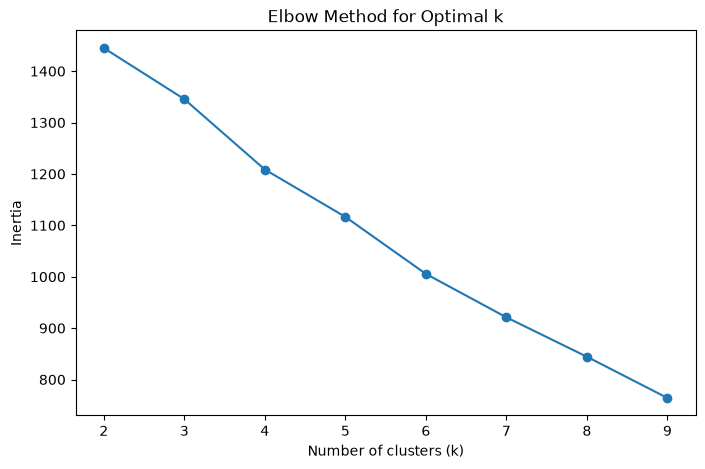

In [7]:
# Scaling all features before clustering — KMeans uses Euclidean
# distance, so features on very different scales (views in the
# millions vs. toxicity_rate between 0-1 vs. binary title flags)
# would let views dominate the distance calculation entirely if left
# unscaled.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Elbow method: trying a range of cluster counts (k) and plotting
# within-cluster variance (inertia) for each, to find a reasonable k
# where adding more clusters stops meaningfully reducing variance.
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [8]:
# The elbow is gradual rather than sharp — a common reality with a
# small dataset (50 videos). k=4 is chosen as a balance: the k=3->4
# drop is still meaningful, while k=4->5 shows diminishing returns,
# and k=4 keeps clusters large enough (avg ~12 videos each) to remain
# interpretable, which matters more than following the curve exactly
# with only 50 data points.
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
video_analysis["cluster"] = kmeans.fit_predict(scaled_features)

print(video_analysis["cluster"].value_counts().sort_index())
print()
print(video_analysis.groupby("cluster")[["toxicity_rate", "views", "likes"]].mean())

cluster
0     2
1    45
2     1
3     2
Name: count, dtype: int64

         toxicity_rate      views         likes
cluster                                        
0             0.043478   691027.5  23059.000000
1             0.060684   910872.6  53721.866667
2             0.039007  1300041.0  45125.000000
3             0.084594   959884.0  73129.500000


In [9]:
numeric_only = video_analysis[["toxicity_rate", "views", "likes"]]
scaled_numeric = StandardScaler().fit_transform(numeric_only)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
video_analysis["cluster"] = kmeans.fit_predict(scaled_numeric)

print(video_analysis["cluster"].value_counts().sort_index())
print()
print(video_analysis.groupby("cluster")[["toxicity_rate", "views", "likes"]].mean())

cluster
0     4
1    20
2    17
3     9
Name: count, dtype: int64

         toxicity_rate         views          likes
cluster                                            
0             0.129101  1.625473e+06  142840.750000
1             0.053678  4.137870e+05   20004.500000
2             0.045137  1.087958e+06   48874.176471
3             0.074293  1.368690e+06   94741.333333


#### Observation: Video Clustering
- Clustering on toxicity_rate, views, and likes (title-based TF-IDF
  features were dropped from the clustering distance metric after an
  initial attempt produced a degenerate result — 45 of 50 videos in one
  cluster — since sparse title features dominated the small set of
  dense numeric signals).
- k=4 produced well-balanced clusters (4, 20, 17, 9 videos).
- Toxicity rate correlates positively with engagement: the two
  highest-toxicity clusters (12.9% and 7.4%) are also the two
  highest-viewed and highest-liked, while the lowest-toxicity cluster
  (4.5%) has moderate engagement. This suggests toxic engagement is not
  incidental to this channel's most-watched content — its most popular
  videos are also its most contentious.

In [10]:
print(video_analysis[video_analysis["cluster"] == 0][["title", "toxicity_rate", "views", "likes"]])

                          title  toxicity_rate    views   likes
10             No Shame at all?       0.107914  2536485  195392
43  Why Are Reporters Targeted?       0.132075  1118121  106635
48                     Shameful       0.187266  1171991  116142
49           Reality was scary!       0.089147  1675294  153194


In [11]:
for c in sorted(video_analysis["cluster"].unique()):
    print(f"--- Cluster {c} ({(video_analysis['cluster']==c).sum()} videos) ---")
    print(video_analysis[video_analysis["cluster"] == c][["title", "toxicity_rate", "views", "likes"]]
          .sort_values("toxicity_rate", ascending=False)
          .to_string(index=False))
    print()

--- Cluster 0 (4 videos) ---
                      title  toxicity_rate   views  likes
                   Shameful       0.187266 1171991 116142
Why Are Reporters Targeted?       0.132075 1118121 106635
           No Shame at all?       0.107914 2536485 195392
         Reality was scary!       0.089147 1675294 153194

--- Cluster 1 (20 videos) ---
                                                                                         title  toxicity_rate  views  likes
                                                       What’s happening in Jharkhand Protest 👀       0.106195 176489  15143
                                                                        Isteefa is not enough!       0.090909 464192   7337
                                                       Independence Day Special or Ad Special?       0.086957 862478   7147
                                                              Reality of anti paper leak bill👀       0.081081 110591   5395
Prashant Kishore Wins, Jharkha

#### Conclusion
Clustering revealed that toxicity is driven more by content format and
framing than by raw engagement. Single-issue, emotionally provocative
commentary videos with accusatory titles ("Shameful", "Why Are
Reporters Targeted?", "Is This Democracy?!") consistently show the
highest toxicity rates (up to 18.7%), while multi-topic "Sunday Show"/
"Midweek" roundup videos — despite comparable or higher view counts —
are consistently the calmest (as low as 2.6%). This suggests that for
this channel, provoking sustained outrage around a single incident
draws proportionally more toxic reaction than a broader, multi-topic
digest format, even when both reach similarly large audiences.